In [22]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("default")


In [23]:
fund_master = pd.read_csv(
    "../data/raw/01_fund_master.csv"
)

nav = pd.read_csv(
    "../data/processed/02_nav_history_clean.csv"
)

aum = pd.read_csv(
    "../data/raw/03_aum_by_fund_house.csv"
)

sip = pd.read_csv(
    "../data/raw/04_monthly_sip_inflows.csv"
)

category = pd.read_csv(
    "../data/raw/05_category_inflows.csv"
)

folios = pd.read_csv(
    "../data/raw/06_industry_folio_count.csv"
)

performance = pd.read_csv(
    "../data/raw/07_scheme_performance.csv"
)

transactions = pd.read_csv(
    "../data/raw/08_investor_transactions.csv"
)

holdings = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

In [24]:
nav["date"] = pd.to_datetime(nav["date"])

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022-2026)"
)

fig.show()

In [25]:
fig.write_image(
    "../reports/charts/nav_trends.png"
)

## Insight 1

Most mutual fund schemes exhibited strong NAV appreciation during the 2023 bull market, while temporary corrections were observed during 2024 before growth resumed.
Reference: Chart 1 – Daily NAV Trend Analysis

In [26]:
aum["year"] = pd.to_datetime(
    aum["date"]
).dt.year

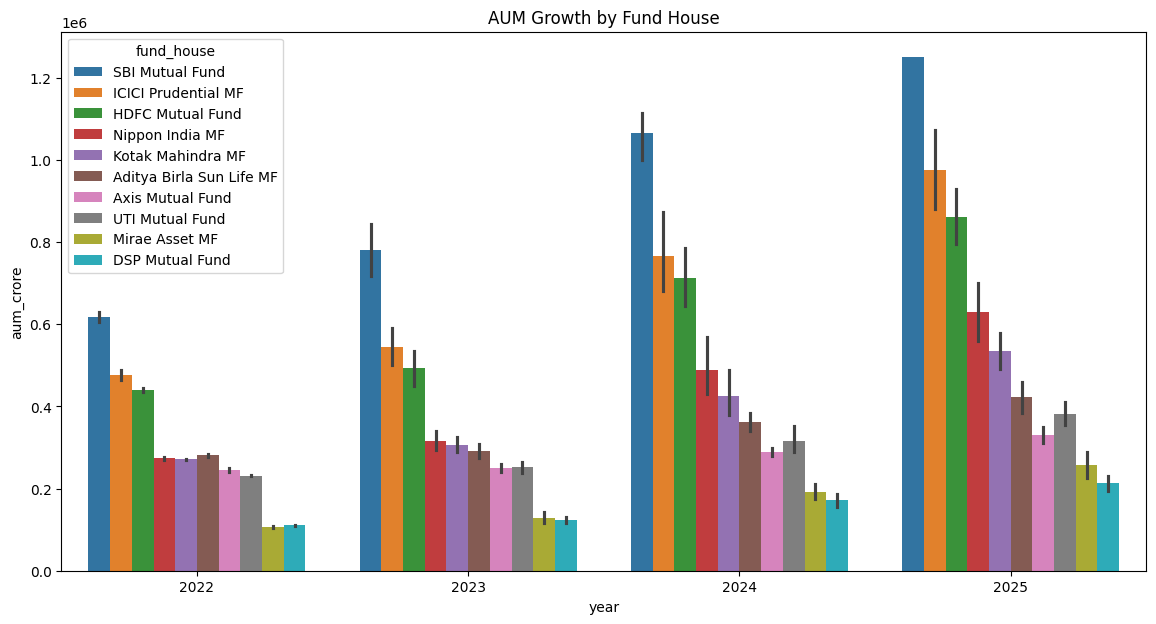

In [27]:
plt.figure(figsize=(14,7))

sns.barplot(
    data=aum,
    x="year",
    y="aum_crore",
    hue="fund_house"
)

plt.title(
    "AUM Growth by Fund House"
)

plt.savefig(
    "../reports/charts/aum_growth.png"
)

plt.show()

## Insight 2

SBI Mutual Fund consistently maintained the highest Assets Under Management (AUM) among all fund houses, reaching industry-leading levels by 2025.
Reference: Chart 2 – AUM Growth by Fund House

In [28]:
sip["month"] = pd.to_datetime(
    sip["month"]
)

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows"
)
fig.write_image(
    "../reports/charts/sip_trend.png"
)

fig.show()

In [29]:
highest = sip.loc[
    sip["sip_inflow_crore"].idxmax()
]

## Insight 3

Monthly SIP inflows showed sustained growth throughout the period and reached an all-time high of ₹31,002 crore in December 2025.
Reference: Chart 3 – Monthly SIP Inflow Trend

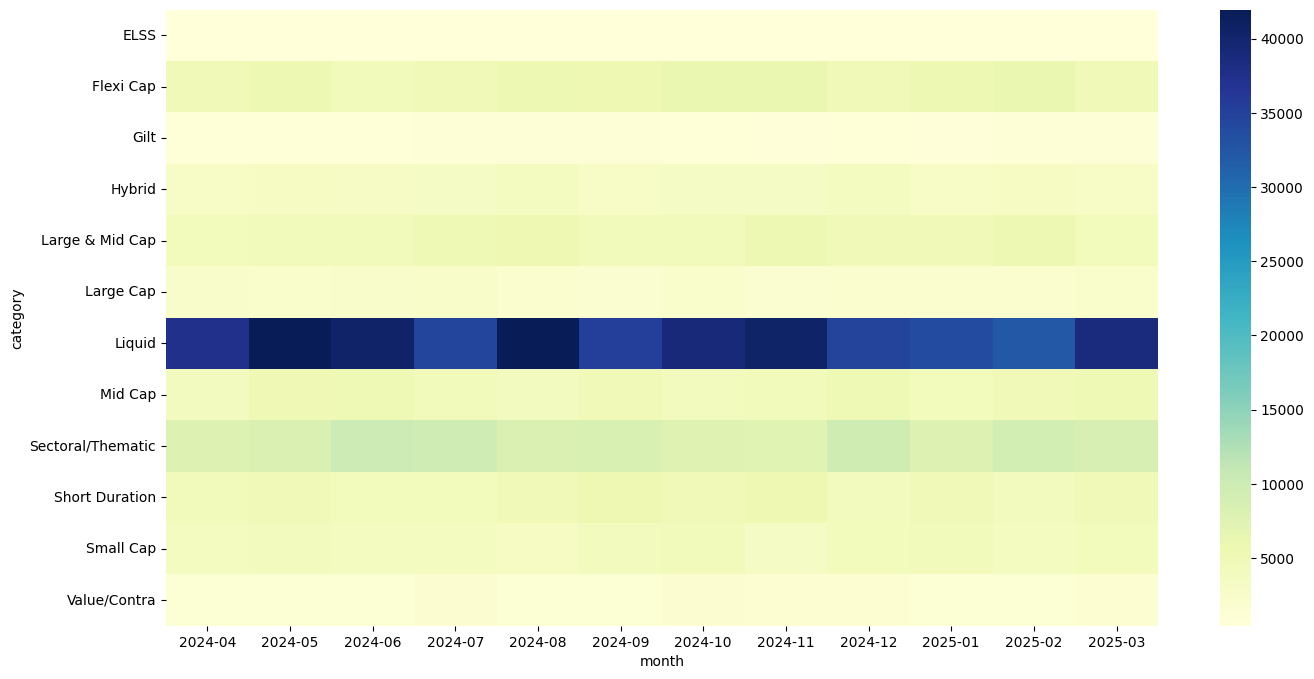

In [30]:
pivot = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(16,8))

sns.heatmap(
    pivot,
    cmap="YlGnBu"
)

plt.savefig(
    "../reports/charts/category_heatmap.png"
)

## Insight 4

Flexi Cap, Mid Cap, and Small Cap categories attracted consistently strong investor inflows compared to other categories.
Reference: Chart 4 – Category Inflow Heatmap

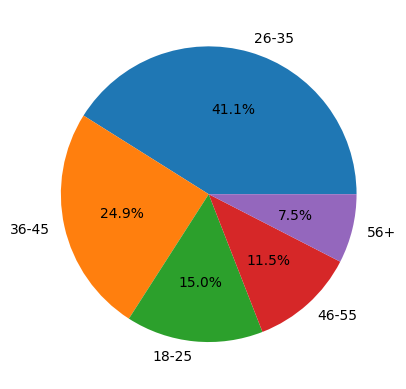

In [31]:
transactions[
    "age_group"
].value_counts().plot.pie(
    autopct="%1.1f%%"
)
plt.savefig(
    "../reports/charts/age_group_pie.png",
    bbox_inches="tight"
)

plt.show()


## Insight 5

Investors belonging to the middle-age brackets contributed the largest share of mutual fund participation.
Reference: Chart 5 – Age Group Distribution

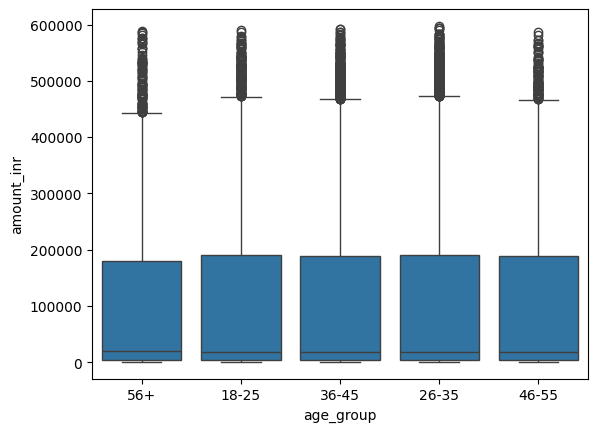

In [32]:
sns.boxplot(
    data=transactions,
    x="age_group",
    y="amount_inr"
)
plt.savefig(
    "../reports/charts/sip_boxplot.png",
    bbox_inches="tight"
)

plt.show()

## Insight 6

Higher transaction amounts were generally concentrated among older and higher-income investor groups.
Reference: Chart 6 – SIP Amount Box Plot by Age Group

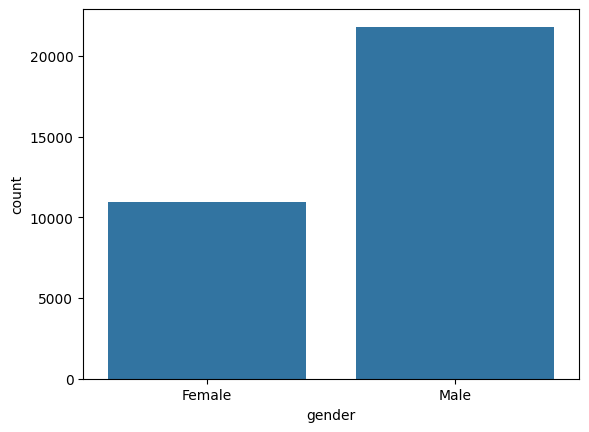

In [33]:
sns.countplot(
    data=transactions,
    x="gender"
)
plt.savefig(
    "../reports/charts/gender_split.png",
    bbox_inches="tight"
)

plt.show()

## Insight 7

Male investors accounted for a larger proportion of transactions, although female participation remains significant.
Reference: Chart 7 – Gender Distribution

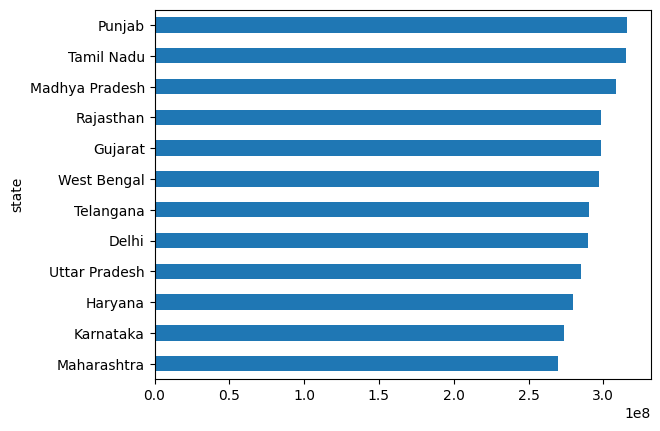

In [34]:
state_data = (
    transactions
    .groupby("state")
    ["amount_inr"]
    .sum()
    .sort_values()
)

state_data.plot.barh()

plt.savefig(
    "../reports/charts/state_distribution.png",
    bbox_inches="tight"
)

plt.show()

## Insight 8

A small number of states contributed a disproportionately large share of total investment inflows.
Reference: Chart 8 – State-wise Investment Distribution

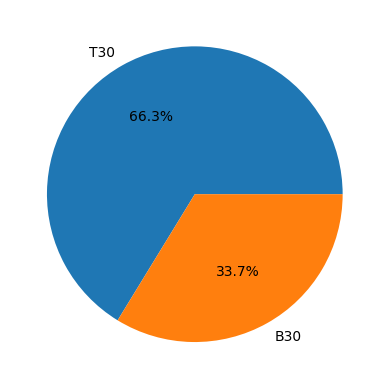

In [35]:
transactions[
    "city_tier"
].value_counts().plot.pie(
    autopct="%1.1f%%"
)
plt.savefig(
    "../reports/charts/city_tier_pie.png",
    bbox_inches="tight"
)

plt.show()

## Insight 9

Total mutual fund folios nearly doubled from 13.26 crore in January 2022 to over 26 crore by December 2025, indicating strong retail participation.
Reference: Chart 9 – Industry Folio Growth

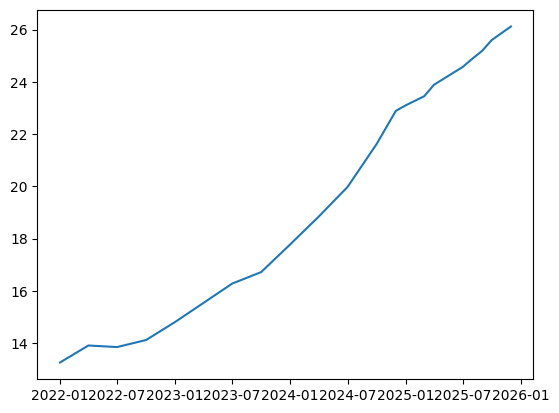

In [36]:
folios["month"] = pd.to_datetime(
    folios["month"]
)

plt.plot(
    folios["month"],
    folios["total_folios_crore"]
)
plt.savefig(
    "../reports/charts/folio_growth.png",
    bbox_inches="tight"
)

plt.show()

## Insight 10

Large-cap equity funds exhibited high return correlation, while sector allocations remained diversified across banking, technology, healthcare, and industrial sectors.
Reference: Chart 10 – Return Correlation Matrix and Sector Allocation Analysis

In [37]:
returns = (
    nav
    .pivot(
        index="date",
        columns="amfi_code",
        values="nav"
    )
    .pct_change()
)

corr = returns.corr()
plt.savefig(
    "../reports/charts/correlation_matrix.png",
    bbox_inches="tight"
)

plt.show()

<Figure size 640x480 with 0 Axes>

<Axes: xlabel='amfi_code', ylabel='amfi_code'>

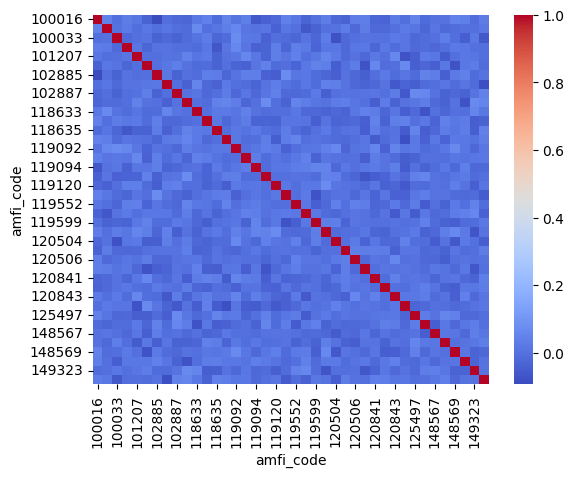

In [38]:
sns.heatmap(
    corr,
    cmap="coolwarm"
)


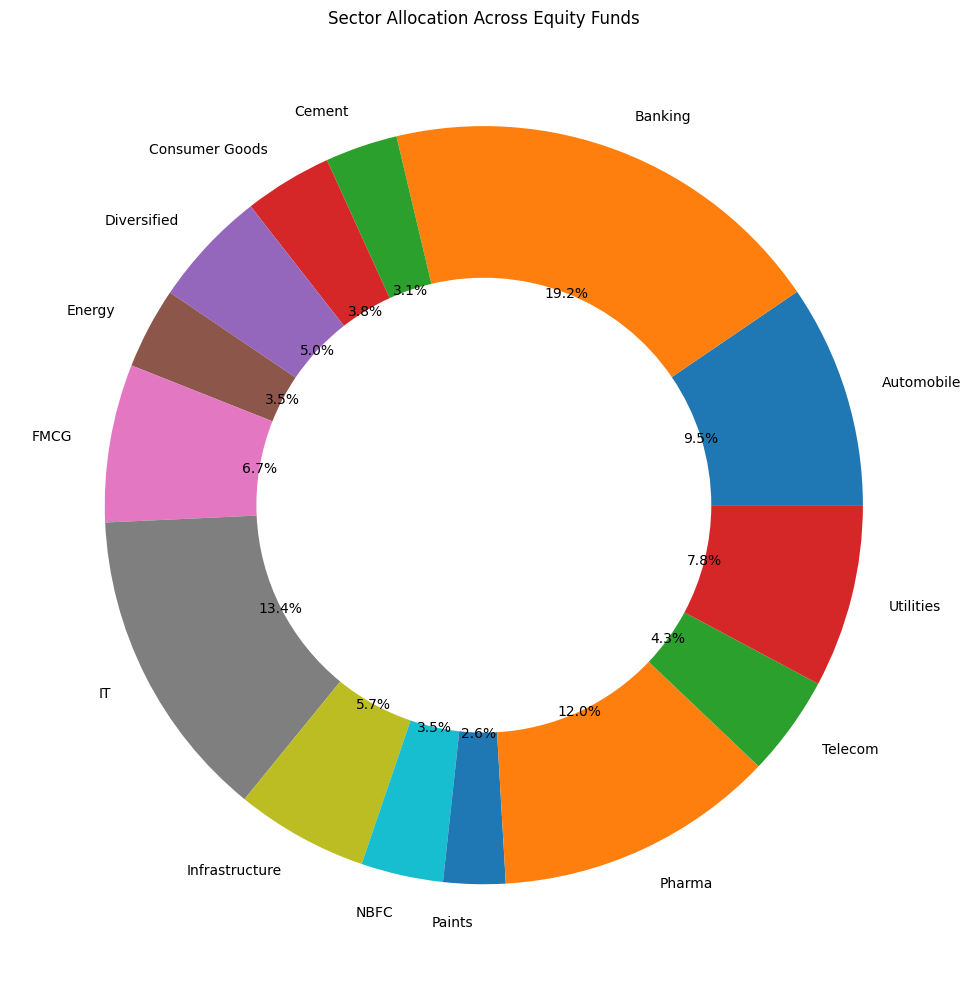

In [39]:
sector = (
    holdings.groupby("sector")
    ["weight_pct"]
    .sum()
)

plt.figure(figsize=(10,10))

plt.pie(
    sector,
    labels=sector.index,
    autopct="%1.1f%%",
    wedgeprops={"width":0.4}
)

plt.title(
    "Sector Allocation Across Equity Funds"
)

plt.tight_layout()

plt.savefig(
    "../reports/charts/sector_allocation.png",
    bbox_inches="tight"
)

plt.show()

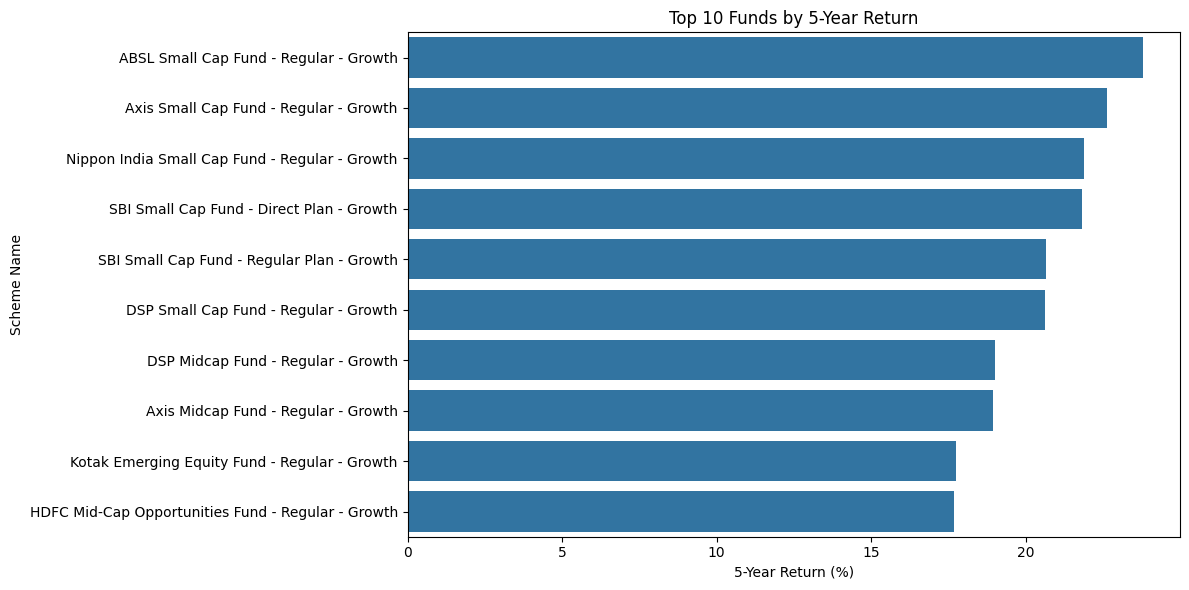

In [40]:
top10 = performance.nlargest(
    10,
    "return_5yr_pct"
)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="return_5yr_pct",
    y="scheme_name"
)

plt.title(
    "Top 10 Funds by 5-Year Return"
)

plt.xlabel("5-Year Return (%)")
plt.ylabel("Scheme Name")

plt.tight_layout()

plt.savefig(
    "../reports/charts/top_performing_funds.png",
    bbox_inches="tight"
)

plt.show()

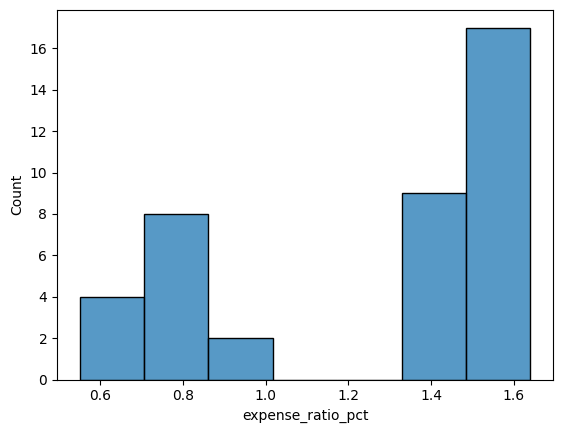

In [41]:
sns.histplot(
    performance["expense_ratio_pct"]
)
plt.savefig(
    "../reports/charts/expense_ratio_distribution.png",
    bbox_inches="tight"
)

plt.show()

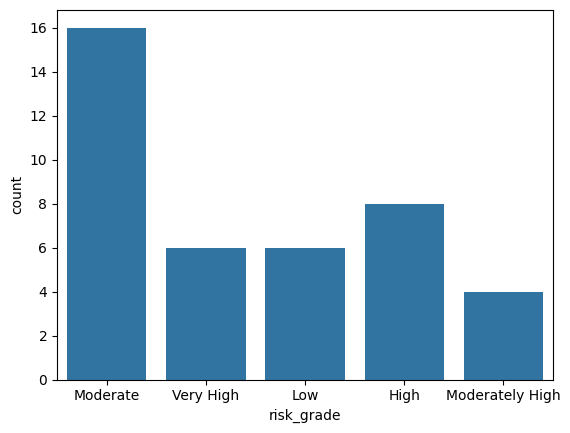

In [42]:
sns.countplot(
    data=performance,
    x="risk_grade"
)
plt.savefig(
    "../reports/charts/risk_category_distribution.png",
    bbox_inches="tight"
)

plt.show()